In [87]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv("spotify_data clean.csv")

In [91]:
def parse_genres(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x 
    return [g.strip() for g in str(x).split(",")]

df["artist_genres"] = df["artist_genres"].apply(parse_genres)

genre_counts = Counter()
for genres in df["artist_genres"]:
    for g in genres:
        genre_counts[g] += 1

MIN_GENRE_FREQ = 3
MIN_GENRES_PER_ARTIST = 1
MAX_GENRES_PER_ARTIST = 6

valid_genres = {g for g, c in genre_counts.items() if c >= MIN_GENRE_FREQ}

df["artist_genres"] = df["artist_genres"].apply(
    lambda genres: [g for g in genres if g in valid_genres]
)

df = df[df["artist_genres"].apply(len) >= MIN_GENRES_PER_ARTIST]
df["artist_genres"] = df["artist_genres"].apply(
    lambda genres: genres[:MAX_GENRES_PER_ARTIST]
)

G = nx.Graph()
for _, row in df.iterrows():
    artist = row["artist_name"]
    genres = row["artist_genres"]
    for genre in genres:
        G.add_edge(artist, genre)

In [95]:
artists = set(df["artist_name"])

closeness_centrality = nx.closeness_centrality(G)

artist_close = {
    node: score
    for node, score in closeness_centrality.items()
    if node in artists
}

top_close = sorted(artist_close.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 artists by Closeness centrality:")
for artist, score in top_close:
    print(artist, score)


Top 10 artists by Closeness centrality:
Post Malone 0.12774061609297674
Taylor Swift 0.12728265499321703
Lady Gaga 0.12301931820088245
PJ Harvey 0.12279239762315428
The Weeknd 0.12153140768863993
The White Stripes 0.12153140768863993
Pink Floyd 0.12153140768863993
Sonic Youth 0.12081457089192833
Foo Fighters 0.12018745847249383
R.E.M. 0.11991682695150195


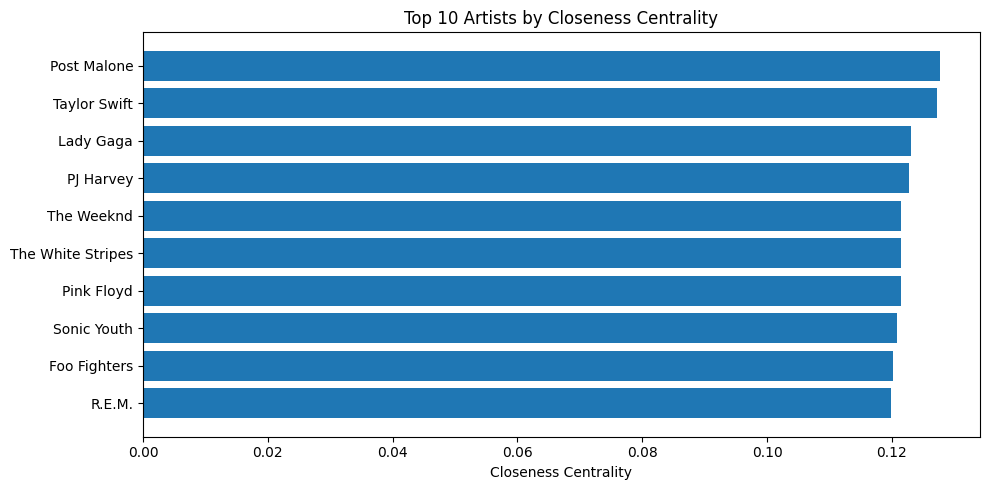

In [94]:
top_close = sorted(artist_close.items(), key=lambda x: x[1], reverse=True)[:10]

artists_close = [x[0] for x in top_close]
scores_close = [x[1] for x in top_close]

plt.figure(figsize=(10,5))
plt.barh(artists_close, scores_close)
plt.xlabel("Closeness Centrality")
plt.title("Top 10 Artists by Closeness Centrality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [96]:
betweenness = nx.betweenness_centrality(G)

artist_betweenness = {
    node: score
    for node, score in betweenness.items()
    if node in artists
}

top_bridge = sorted(artist_betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 artists by betweeness centrality:")
for artist, score in top_bridge:
    print(artist, score)


Top 10 artists by betweeness centrality:
Taylor Swift 0.11917940718171316
Charli xcx 0.11709029811363235
Post Malone 0.11704297482775518
Odetari 0.11375241129285237
Rihanna 0.07345583193158695
Kyle Dixon & Michael Stein 0.06777362243170226
The Weeknd 0.06603312167383789
Lady Gaga 0.06367594553880508
Vestron Vulture 0.0617820995301873
Miley Cyrus 0.05267693273035619


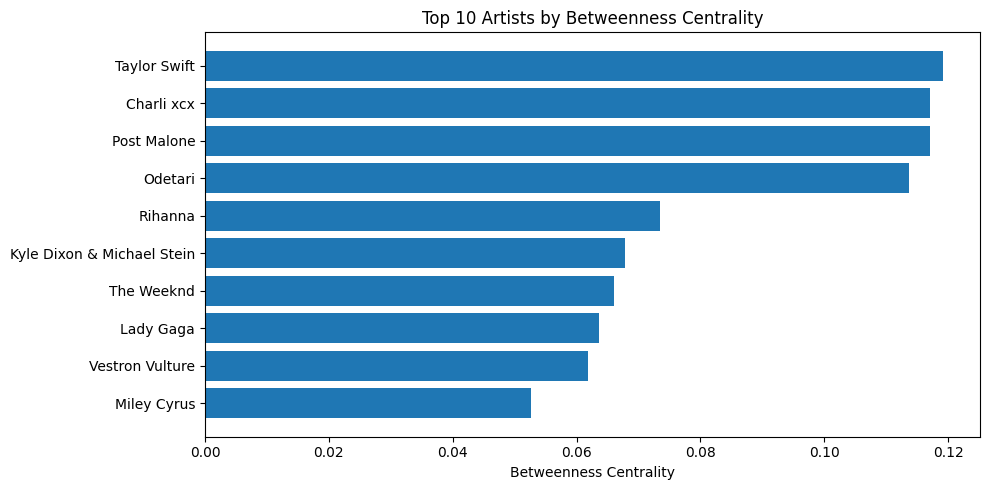

In [97]:
top_bridge = sorted(artist_betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

artists_bet = [x[0] for x in top_bridge]
scores_bet = [x[1] for x in top_bridge]

plt.figure(figsize=(10,5))
plt.barh(artists_bet, scores_bet)
plt.xlabel("Betweenness Centrality")
plt.title("Top 10 Artists by Betweenness Centrality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [98]:
pagerank = nx.pagerank(G)

artist_pr = {node: score for node, score in pagerank.items() if node in artists}

top_pr = sorted(artist_pr.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 artists by Page Rank")
for artist, score in top_pr:
    print(artist, score)

Top 10 artists by Page Rank
Anitta 0.0012909979064898813
Virtual Riot 0.0012541570259044718
Wizkid 0.001141818606308048
The Chemical Brothers 0.0011298393523826254
Link Wray 0.0011080280445785343
Alok 0.0011003141706648675
Brian Eno 0.001072485359881754
Billie Eilish 0.001019745789566398
Black Sabbath 0.001018903552148134
Whiskey Myers 0.0009908191815134577


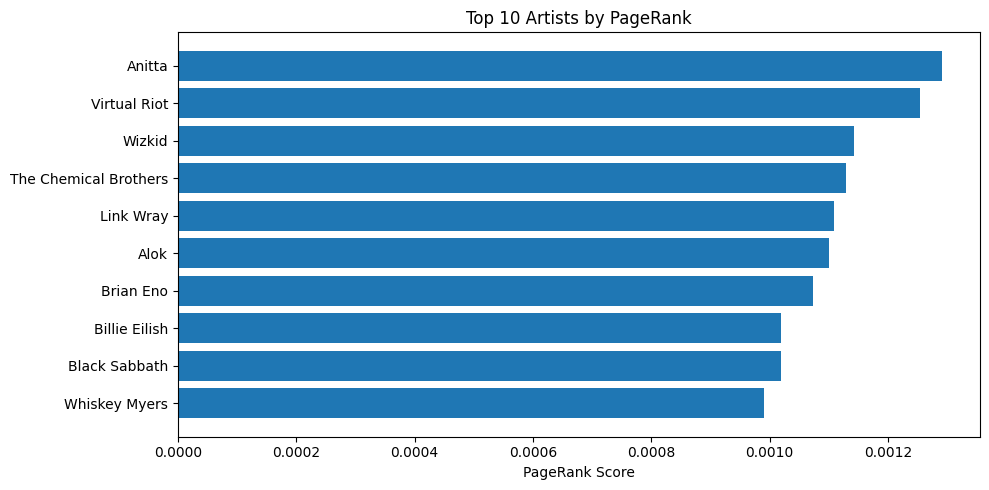

In [99]:
top_pr = sorted(artist_pr.items(), key=lambda x: x[1], reverse=True)[:10]

artists_pr = [x[0] for x in top_pr]
scores_pr = [x[1] for x in top_pr]

plt.figure(figsize=(10,5))
plt.barh(artists_pr, scores_pr)
plt.xlabel("PageRank Score")
plt.title("Top 10 Artists by PageRank")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

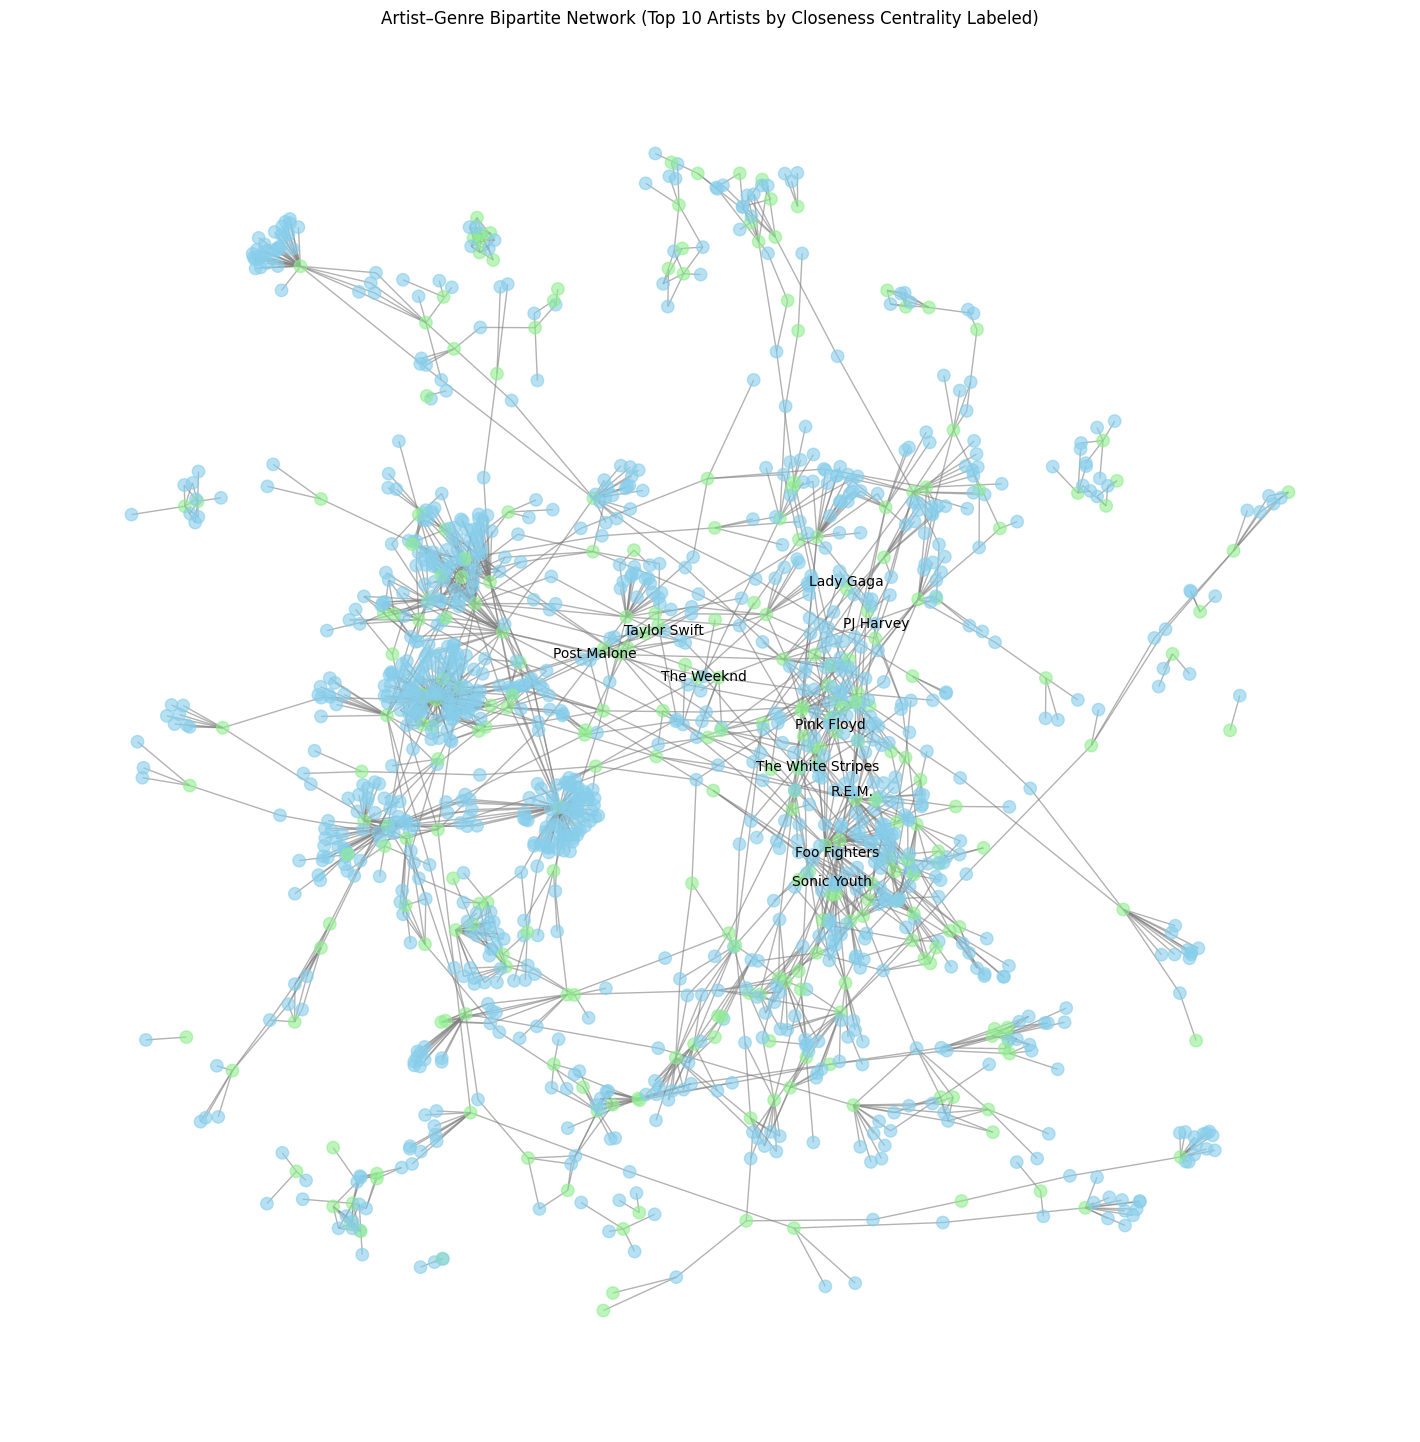

In [101]:
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.35, seed=42)

artist_nodes = set(df["artist_name"])
node_colors = ["skyblue" if n in artist_nodes else "lightgreen" for n in G.nodes()]

nx.draw(
    G, pos,
    node_color=node_colors,
    node_size=80,
    edge_color="gray",
    alpha=0.6,
    with_labels=False
)

labels = {artist: artist for artist, score in top_close}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

plt.title("Artist–Genre Bipartite Network (Top 10 Artists by Closeness Centrality Labeled)")
plt.show()


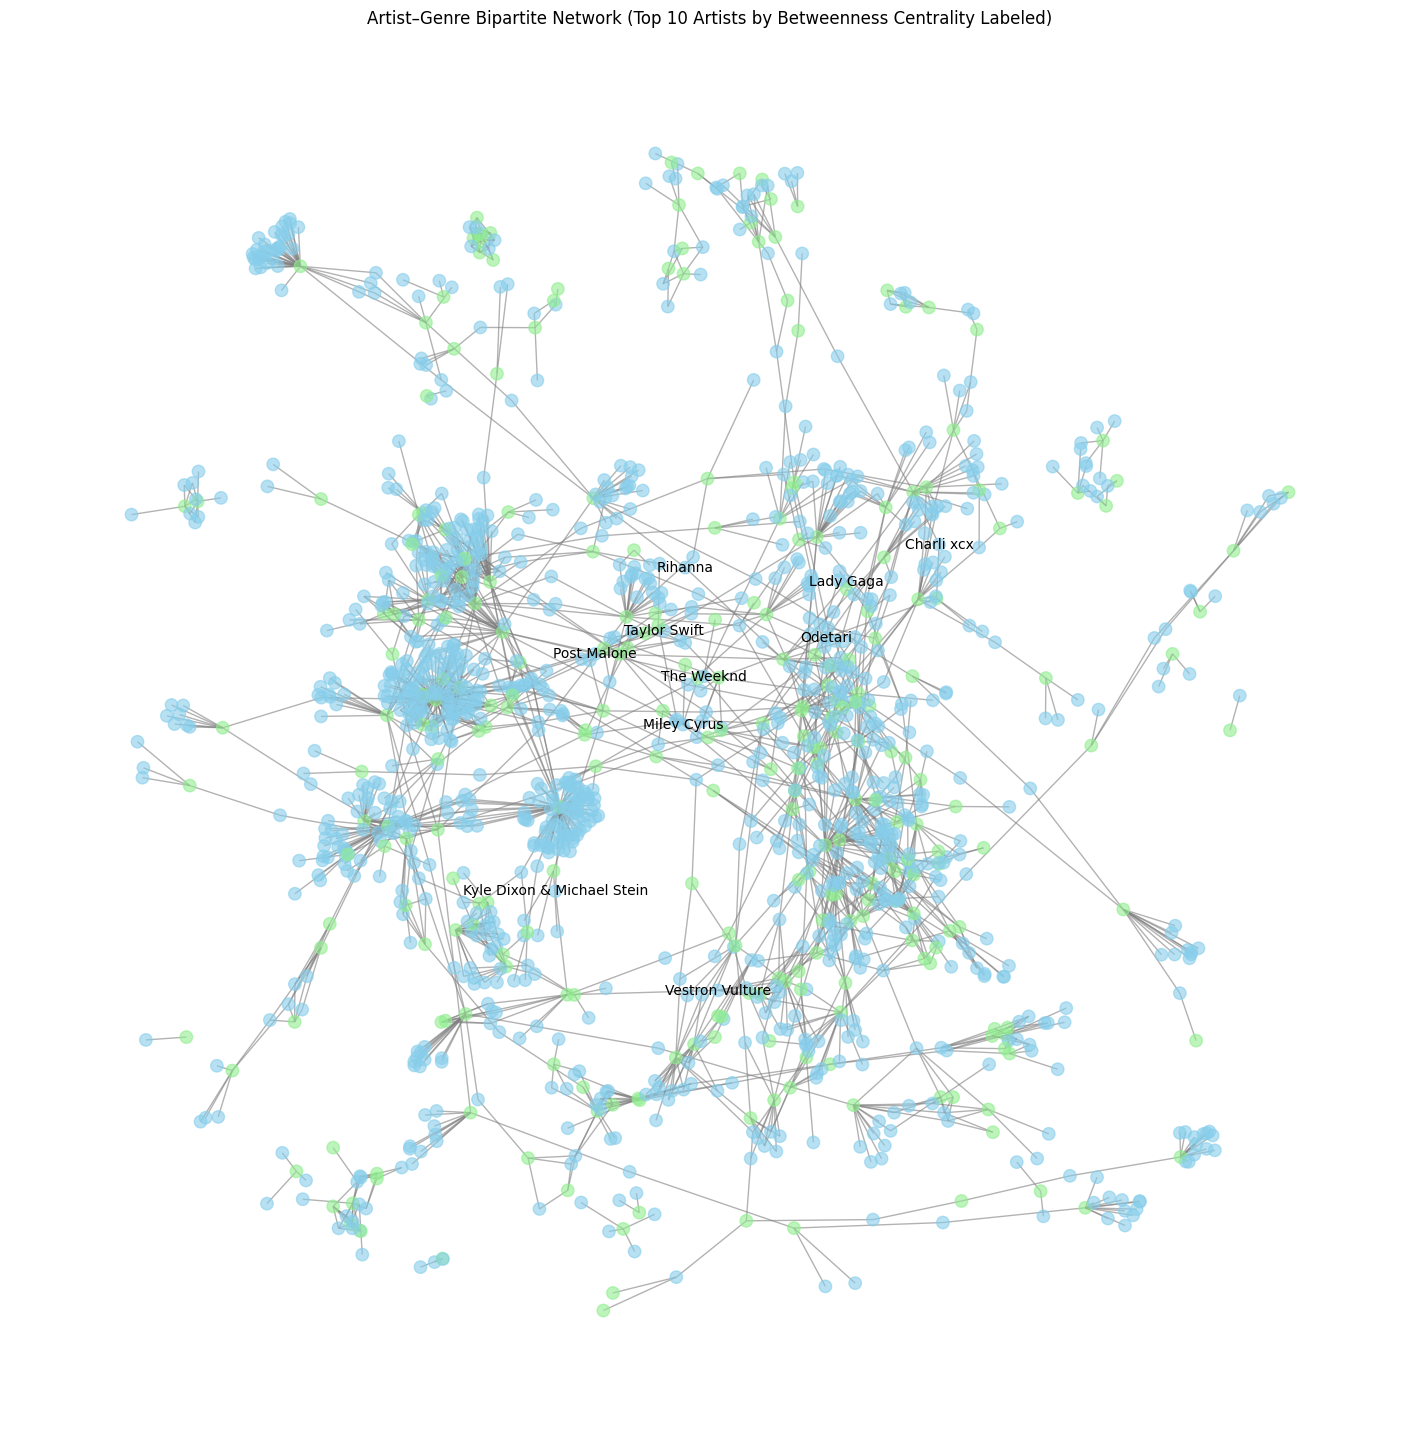

In [102]:
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.35, seed=42)

artist_nodes = set(df["artist_name"])
node_colors = ["skyblue" if n in artist_nodes else "lightgreen" for n in G.nodes()]

nx.draw(
    G, pos,
    node_color=node_colors,
    node_size=80,
    edge_color="gray",
    alpha=0.6,
    with_labels=False
)

labels = {artist: artist for artist, score in top_bridge}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

plt.title("Artist–Genre Bipartite Network (Top 10 Artists by Betweenness Centrality Labeled)")
plt.show()


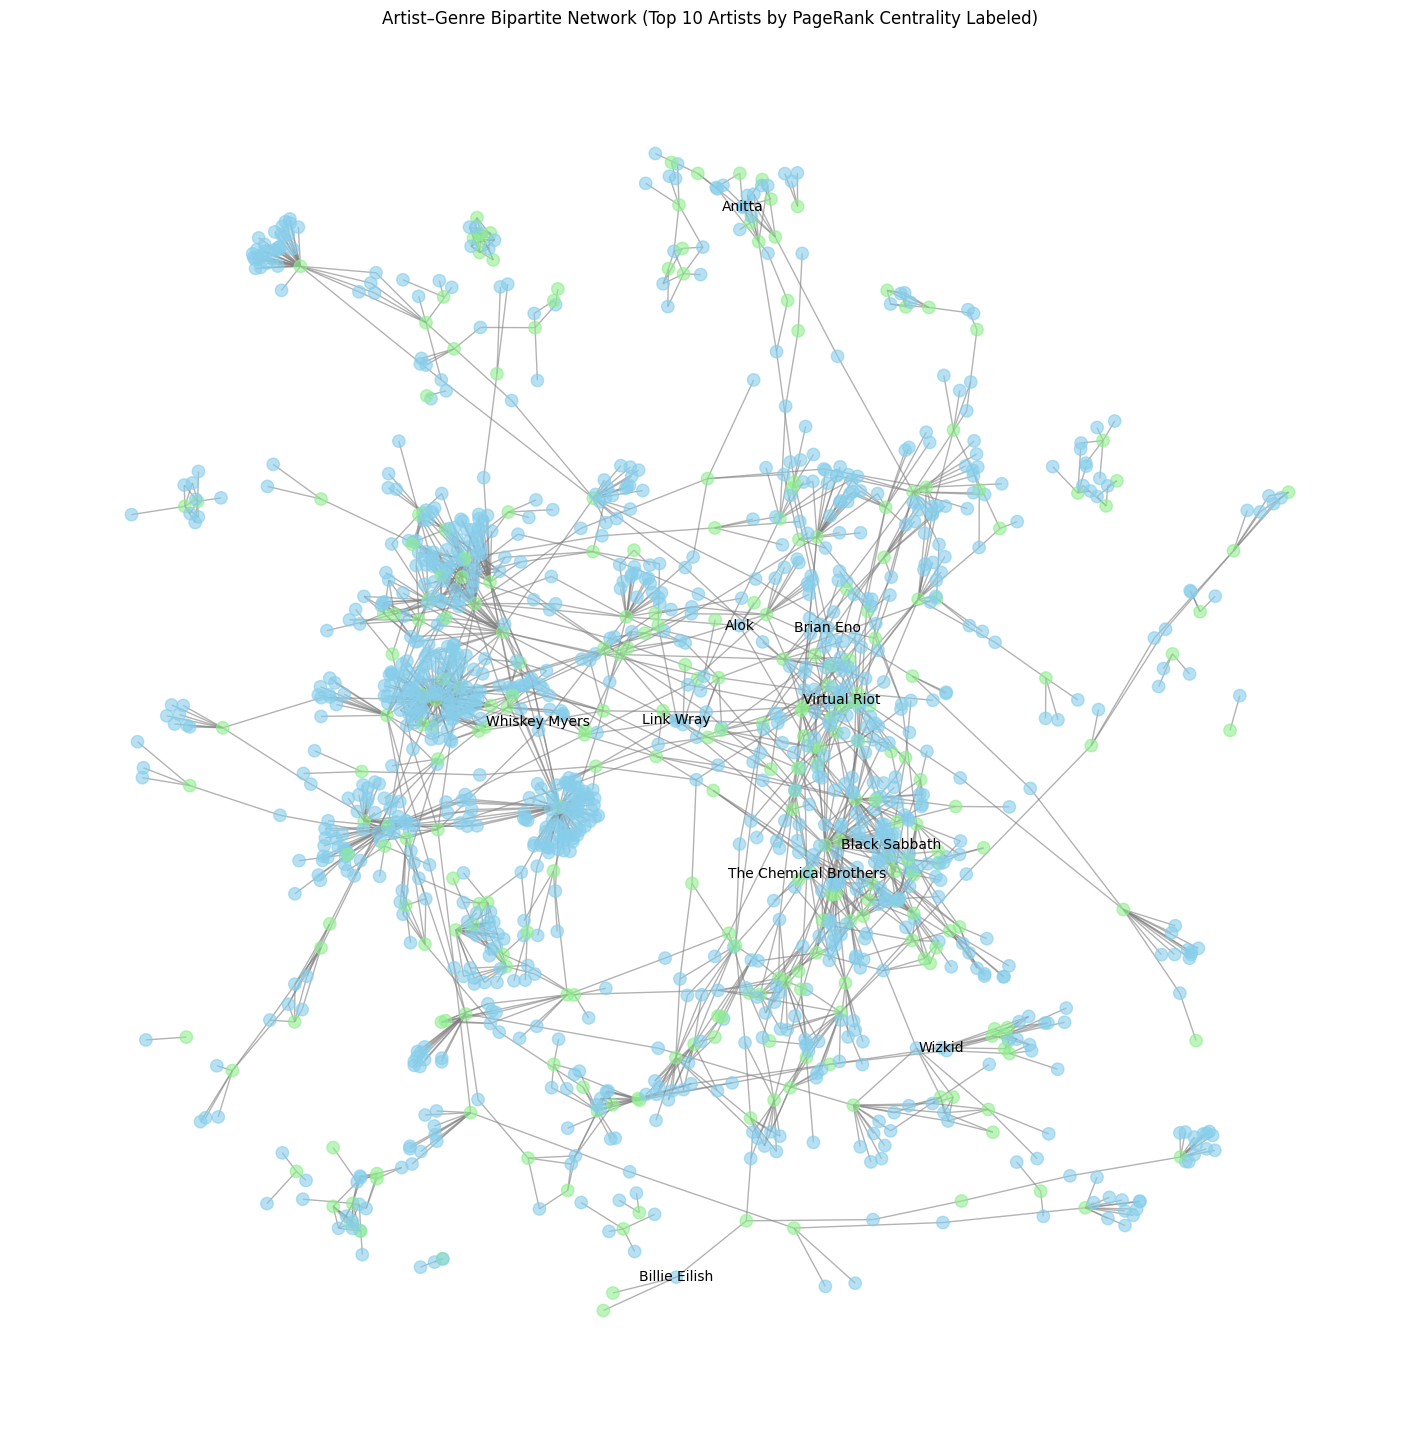

In [103]:
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.35, seed=42)

artist_nodes = set(df["artist_name"])
node_colors = ["skyblue" if n in artist_nodes else "lightgreen" for n in G.nodes()]

nx.draw(
    G, pos,
    node_color=node_colors,
    node_size=80,
    edge_color="gray",
    alpha=0.6,
    with_labels=False
)

labels = {artist: artist for artist, score in top_pr}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

plt.title("Artist–Genre Bipartite Network (Top 10 Artists by PageRank Centrality Labeled)")
plt.show()
